<a href="https://colab.research.google.com/github/SudoAlluri/Mental_Health_Analysis/blob/main/CrimeNN_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uploading files to Colab

To upload your `mental_health_dataset.xlsx` (or `.csv` if it's a CSV) file to your Colab session, you can use the following code:

*   Click the folder icon on the left sidebar to open the file browser.
*   Click the "Upload to session storage" icon (a page with an arrow pointing up) and select your file.

Alternatively, you can use the `files.upload()` function from `google.colab`:


In [ ]:
from google.colab import files

# This will open a file selection dialog. Choose your 'mental_health_dataset.xlsx' file.
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving mental_health_dataset.csv to mental_health_dataset (3).csv
User uploaded file "mental_health_dataset (3).csv" with length 608866 bytes


In [ ]:
# All the necessary imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
import matplotlib.pyplot as plt

In [ ]:
# Import the dataset file
data = pd.read_csv('mental_health_dataset.csv')

In [ ]:
# Look at the data
data.head()

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High


### chatgpt code


In [ ]:
'''risk_encoder = LabelEncoder()
y_encoded = risk_encoder.fit_transform(data["mental_health_risk"])

print("Classes:", risk_encoder.classes_)


onehot = OneHotEncoder(sparse_output=False)
y = onehot.fit_transform(y_encoded.reshape(-1, 1))'''

'risk_encoder = LabelEncoder()\ny_encoded = risk_encoder.fit_transform(data["mental_health_risk"])\n\nprint("Classes:", risk_encoder.classes_)\n\n\nonehot = OneHotEncoder(sparse_output=False)\ny = onehot.fit_transform(y_encoded.reshape(-1, 1))'

In [ ]:
'''label_cols = [
    "gender",
    "employment_status",
    "work_environment",
    "mental_health_history",
    "seeks_treatment"
]
encoders = {}

for col in label_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le'''


'label_cols = [\n    "gender",\n    "employment_status",\n    "work_environment",\n    "mental_health_history",\n    "seeks_treatment"\n]\nencoders = {}\n\nfor col in label_cols:\n    le = LabelEncoder()\n    data[col] = le.fit_transform(data[col])\n    encoders[col] = le'

In [ ]:
'''features = [
    "age",
    "gender",
    "employment_status",
    "work_environment",
    "mental_health_history",
    "seeks_treatment",
    "stress_level",
    "sleep_hours",
    "physical_activity_days",
    "depression_score",
    "anxiety_score",
    "social_support_score",
    "productivity_score"
]

X = data[features].values'''

'features = [\n    "age",\n    "gender",\n    "employment_status",\n    "work_environment",\n    "mental_health_history",\n    "seeks_treatment",\n    "stress_level",\n    "sleep_hours",\n    "physical_activity_days",\n    "depression_score",\n    "anxiety_score",\n    "social_support_score",\n    "productivity_score"\n]\n\nX = data[features].values'

In [ ]:
'''X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)'''

'X_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42\n)\n\nscaler = MinMaxScaler()\n\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)'

In [ ]:
'''model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)'''

"model = Sequential([\n    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),\n    Dense(512, activation='relu'),\n    Dense(256, activation='relu'),\n    Dense(3, activation='softmax')\n])\nmodel.compile(\n    optimizer='adam',\n    loss='categorical_crossentropy',\n    metrics=['accuracy']\n)"

In [ ]:
'''
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")'''

'\nhistory = model.fit(\n    X_train, y_train,\n    epochs=20,\n    batch_size=32,\n    validation_split=0.2,\n    verbose=1\n)\nloss, accuracy = model.evaluate(X_test, y_test)\nprint(f"Test Loss: {loss:.4f}")\nprint(f"Test Accuracy: {accuracy:.4f}")'

In [ ]:
'''from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true_labels, y_pred_labels))

print("Confusion Matrix:")
print(confusion_matrix(y_true_labels, y_pred_labels))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Curve")
plt.show()'''

'from sklearn.metrics import classification_report, confusion_matrix\n\nprint(classification_report(y_true_labels, y_pred_labels))\n\nprint("Confusion Matrix:")\nprint(confusion_matrix(y_true_labels, y_pred_labels))\n\nplt.plot(history.history[\'loss\'], label=\'train loss\')\nplt.plot(history.history[\'val_loss\'], label=\'val loss\')\nplt.legend()\nplt.title("Loss Curve")\nplt.show()'

In [ ]:
'''loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)'''

'loss, accuracy = model.evaluate(X_test, y_test, verbose=0)\n\nprint("Test Loss:", loss)\nprint("Test Accuracy:", accuracy)'

In [ ]:
'''y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)'''

'y_pred_probs = model.predict(X_test)\ny_pred_classes = np.argmax(y_pred_probs, axis=1)'

In [ ]:
'''y_true_classes = np.argmax(y_test, axis=1)

from sklearn.metrics import classification_report

print(classification_report(y_true_classes, y_pred_classes))

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_true_classes, y_pred_classes))

for i in range(10):
    print("Pred:", y_pred_classes[i], "Actual:", y_true_classes[i])'''

'y_true_classes = np.argmax(y_test, axis=1)\n\nfrom sklearn.metrics import classification_report\n\nprint(classification_report(y_true_classes, y_pred_classes))\n\nfrom sklearn.metrics import confusion_matrix\n\nprint(confusion_matrix(y_true_classes, y_pred_classes))\n\nfor i in range(10):\n    print("Pred:", y_pred_classes[i], "Actual:", y_true_classes[i])'

## Done chatgpt

In [ ]:
# Now we need to massage the data a little bit and prepare it for our nueral network
# The first through fourth and eight through eleven columns are good, they are numerical although NN like the
# data to be between 0 and 1 so we'll just scale them
# We need to "label encode" columns two through six
# In this first example our "y" is going to be "OFFENSE" and everything else will be "x"


# age feature to float
x1 = np.array(data['age'], dtype = float)
x1 = x1/max(x1)

# stress level feature to float
x7 = np.array(data['stress_level'], dtype=float)
x7 = x7/max(x7)
# sleep hours feature to float which is already in float
x8= np.array(data['sleep_hours'], dtype=float)
x8= x8/max(x8)
# physical activity days to float
x9= np.array(data['physical_activity_days'], dtype=float)
x9= x9/max(x9)
# depression feature  to float
x10= np.array(data['depression_score'], dtype=float)
x10= x10/max(x10)
# anxiety feature to float
x11= np.array(data['anxiety_score'], dtype=float)
x11= (x11)/max(x11)
# social support to float
x12= np.array(data['social_support_score'], dtype=float)
x12= (x12)/max(x12)
# productivity sscore to float
x13= np.array(data['productivity_score'], dtype=float)
x13= (x13)/max(x13)


In [ ]:
# This cell now contains the corrected `predict_risk` function definition.
# Please run this cell first before attempting to call `predict_risk` from other cells.

import pandas as pd
import numpy as np

# Max values for numerical features, consistent with manual scaling in cell 27dbba88
age_max = 65.0 # From data['age'].max()
stress_level_max = 10.0 # From data['stress_level'].max()
sleep_hours_max = 9.0 # From data['sleep_hours'].max()
physical_activity_days_max = 7.0 # From data['physical_activity_days'].max()
depression_score_max = 30.0 # From data['depression_score'].max()
anxiety_score_max = 21.0 # From data['anxiety_score'].max()
social_support_score_max = 95.0 # From data['social_support_score'].max()
productivity_score_max = 100.0 # From data['productivity_score'].max()

# Max encoded values for categorical features, observed from np.unique(encoded_feature).max()
gender_max_encoded = 3.0 # From np.unique(x2orig).max()
employment_status_max_encoded = 3.0 # From np.unique(x3).max()
work_environment_max_encoded = 2.0 # From np.unique(x4).max()
mental_health_history_max_encoded = 1.0 # From np.unique(x5).max()
seeks_treatment_max_encoded = 1.0 # From np.unique(x6).max()

feature_max_values = {
    "age": age_max,
    "gender": gender_max_encoded,
    "employment_status": employment_status_max_encoded,
    "work_environment": work_environment_max_encoded,
    "mental_health_history": mental_health_history_max_encoded,
    "seeks_treatment": seeks_treatment_max_encoded,
    "stress_level": stress_level_max,
    "sleep_hours": sleep_hours_max,
    "physical_activity_days": physical_activity_days_max,
    "depression_score": depression_score_max,
    "anxiety_score": anxiety_score_max,
    "social_support_score": social_support_score_max,
    "productivity_score": productivity_score_max
}

# The order of features must match the order used when creating the training 'x' array in cell 48d1accf
# which was: x1, x2, x3, x4,x5, x6, x7, x8, x9, x10, x11,x12,x13
feature_names_in_order = [
    "age", "gender", "employment_status", "work_environment",
    "mental_health_history", "seeks_treatment", "stress_level",
    "sleep_hours", "physical_activity_days", "depression_score",
    "anxiety_score", "social_support_score", "productivity_score"
]

def predict_risk(new_input):
    df = pd.DataFrame([new_input])

    # Label encode categorical columns using the pre-fitted encoders (from global 'encoders' dict)
    for col_name, encoder in encoders.items():
        if col_name in df.columns:
            df[col_name] = encoder.transform(df[col_name])

    # Ensure the DataFrame columns are in the correct order to match model's input features
    df_ordered = df[feature_names_in_order]
    X_new = df_ordered.values.astype(float)

    # Manually scale each feature using the pre-defined max_values, consistent with training data
    scaled_X_new = np.zeros_like(X_new, dtype=float)
    for i, feature_name in enumerate(feature_names_in_order):
        value = X_new[0, i]
        max_val = feature_max_values[feature_name]
        scaled_X_new[0, i] = value / max_val if max_val != 0 else value

    # Make prediction using the model trained on similarly scaled data
    pred = model.predict(scaled_X_new)
    pred_class = np.argmax(pred, axis=1)

    # Decode the predicted class back to the original risk label
    return risk_encoder.inverse_transform(pred_class)[0]


In [ ]:
# Now we can encode the label columns
encoders = {}
gender_encoder = LabelEncoder()
x2 = data['gender']
x2 = gender_encoder.fit_transform(x2)
encoders['gender'] = gender_encoder
print(np.unique(x2)) # Looks like we have 4 different GENDERS
x2orig = x2
x2 = x2/max(x2)



[0 1 2 3]


In [ ]:
x2labels = gender_encoder.inverse_transform(x2orig)
x2labels # This is how you get back to the original labels

array(['Male', 'Female', 'Female', ..., 'Female', 'Male', 'Male'],
      dtype=object)

In [ ]:
employment_encoder = LabelEncoder()
x3 = data['employment_status']
x3 = employment_encoder.fit_transform(x3)
encoders['employment_status'] = employment_encoder
print(np.unique(x3)) # 4 different employemnt statuses
x3 = x3/max(x3)

[0 1 2 3]


In [ ]:
environment_encoder = LabelEncoder()
x4 = data['work_environment']
x4 = environment_encoder.fit_transform(x4)
encoders['work_environment'] = environment_encoder
print(np.unique(x4)) # 3 different  labels
x4 = x4/max(x4)

mentalhealth_encoder = LabelEncoder()
x5 = data['mental_health_history']
x5 = mentalhealth_encoder.fit_transform(x5)
encoders['mental_health_history'] = mentalhealth_encoder

print(np.unique(x5)) # 2 categorical labels
x5 = x5/max(x5)

treatment_encoder = LabelEncoder()
x6 = data['seeks_treatment']
x6 = treatment_encoder.fit_transform(x6)
encoders['seeks_treatment'] = treatment_encoder

print(np.unique(x6)) # 2 categorical labels
x6 = x6/max(x6)

[0 1 2]
[0 1]
[0 1]


In [ ]:
# since we are going to try and predict the mental health risk level then we'll also need to one-hot encode the mental health data
risk_encoder = LabelEncoder()
y = data['mental_health_risk']
y = risk_encoder.fit_transform(y)
yorig = y
onehot = OneHotEncoder(sparse_output=False)
y = onehot.fit_transform(y.reshape(-1, 1))
y.shape # What this does is it converts the column into an array where there is a row for each data point and the number
# of columns is the number of unique labels, if the label at that data point matches the risk_encoder there is a one
# in that element, if not then there is a zero. We need the y data to be this way so that implimenting the NN is easy

(10000, 3)

In [ ]:
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size = 0.20, random_state=42)
xTrain, xVal, yTrain, yVal = train_test_split(xTrain, yTrain, test_size = .33, random_state = 21)
print(xTrain.shape)
print(yTrain.shape)

(5360, 13)
(5360, 3)


In [ ]:
model = Sequential()
model.add(Dense(256, input_shape=(13,), activation='relu')) # the number of weights (256) can be adjusted for performance
model.add(Dense(512, activation='relu')) # same here, 512 can be adjusted
model.add(Dense(256, activation='relu')) # same here
model.add(Dense(3, activation='softmax')) # for the last layer we want the number of weights to match the size of y (3) with
# softmax activation since we are predicting classes this will result in a vector of probabilities in y
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,267 (1.02 MB)

 Trainable params: 267,267 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# As you can see above, our model is a dense NN with 3 layers and an output layer, we have 267,267 total trainable weights
# Now all we need to do is train these
# 1st we compile it we need to use catergorical crossentropy for the loss function, we'll use the "adam" optimizer, and the metric we want to track
# during training is accuracy
model.compile(loss = 'categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
# During training we'll use an epoch of 100. This means that the model will be fit 100 times.
epochN = 20
# Now we can call the model fit function
history = model.fit(x = xTrain, y = yTrain, epochs=epochN, validation_data=(xVal, yVal))

Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8687 - loss: 0.3091 - val_accuracy: 0.9227 - val_loss: 0.1731
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9358 - loss: 0.1527 - val_accuracy: 0.9333 - val_loss: 0.1543
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9519 - loss: 0.1140 - val_accuracy: 0.9273 - val_loss: 0.1707
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9392 - loss: 0.1320 - val_accuracy: 0.9523 - val_loss: 0.1076
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9558 - loss: 0.1013 - val_accuracy: 0.9314 - val_loss: 0.1401
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9595 - loss: 0.0986 - val_accuracy: 0.9386 - val_loss: 0.1577
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9578 - loss: 0.1012 - val_accuracy: 0.9682 - val_loss: 0.0827
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9545 - loss: 0.1067 - val_accurac

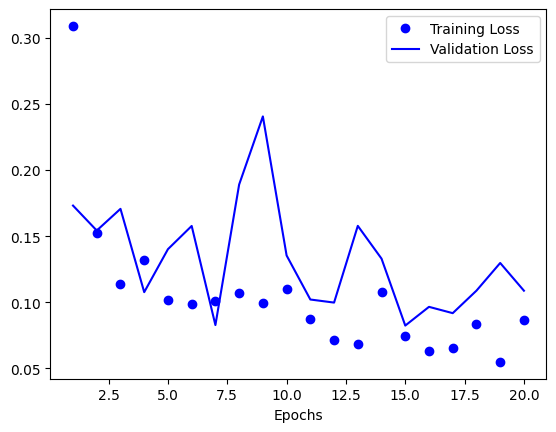

In [ ]:
loss = history.history['loss']
valLoss = history.history['val_loss']
#acc = history.history['acc']
#valAcc = history.history['val_acc']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, valLoss, 'b', label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.show()

In [ ]:
loss, accuracy = model.evaluate(xTrain, yTrain, verbose=0)
print(f"Train Loss: {loss:.4f}")
print(f"Train Accuracy: {accuracy:.4f}")

Train Loss: 0.0602
Train Accuracy: 0.9784


In [ ]:
def predict_risk(new_input):

    df = pd.DataFrame([new_input])

    for col in encoders:
        if col in df.columns:
            df[col] = encoders[col].transform(df[col])

    X_new = df.values
    X_new = scaler.transform(X_new)

    pred = model.predict(X_new)
    pred_class = np.argmax(pred, axis=1)

    return risk_encoder.inverse_transform(pred_class)[0]

In [ ]:
predict_risk({
    "age": 28,
    "gender": "Male",  # Changed from 1 to "Male"
    "employment_status": "Employed", # Changed from 2 to an example string label
    "work_environment": "Remote", # Changed from 1 to an example string label
    "mental_health_history": "No", # Changed from 0 to "No"
    "seeks_treatment": "Yes", # Changed from 1 to "Yes"
    "stress_level": 7,
    "sleep_hours": 5,
    "physical_activity_days": 4,
    "depression_score": 0,
    "anxiety_score": 3,
    "social_support_score": 4,
    "productivity_score": 80
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


'Low'

In [ ]:
# Imports
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Check labels
# -----------------------------
print("Classes:", risk_encoder.classes_)
# Example: ['High' 'Low' 'Medium']

# -----------------------------
# 2. One-hot encode target
# -----------------------------
onehot = OneHotEncoder(sparse_output=False)
y = onehot.fit_transform(yorig.reshape(-1, 1))

print("y shape:", y.shape)

# -----------------------------
# 3. Train-test split
# -----------------------------
x_train, x_test, y_train, y_test, yorig_train, yorig_test = train_test_split(
    x, y, yorig, test_size=0.2, random_state=42
)

# -----------------------------
# 4. Build Neural Network
# -----------------------------
model = Sequential([
    Dense(64, activation='relu', input_shape=(x.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 5. Train model
# -----------------------------
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 6. Evaluate model
# -----------------------------
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# -----------------------------
# 7. Predictions
# -----------------------------
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert back to original labels
y_pred_labels = risk_encoder.inverse_transform(y_pred_classes)
y_true_labels = risk_encoder.inverse_transform(yorig_test)

# -----------------------------
# 8. Metrics
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_labels, y_pred_labels))

In [ ]:
print(f"Proportion of 'High Risk' (1) in yNew: {np.sum(yNew[:, 1]) / len(yNew)}")
print(f"Shape of yNew (binary target): {yNew.shape}")

# Now let's reconsider the x data for this new problem.
# The current x (from cell 48d1accf) includes all 13 features: x1 (age), x2 (gender), x3 (employment_status),
# x4 (work_environment), x5 (mental_health_history), x6 (seeks_treatment),
# x7 (stress_level), x8 (sleep_hours), x9 (physical_activity_days),
# x10 (depression_score), x11 (anxiety_score), x12 (social_support_score), x13 (productivity_score).
# We can reuse this 'x' as our feature set for the new binary prediction problem.
# If a simplified xNew is desired, we can define it here. For now, let's keep all features.
xNew = x # Reusing the previously prepared 'x' with all 13 features.
print(f"Shape of xNew: {xNew.shape}")

In [ ]:
print(sum(yNew[:,0])/len(yNew))
# Alright, it looks like about 35% of these crimes are violent
print(yNew.shape)
# Also, lets think about the x data a little. The incident number really doesn't tell us any thing about the crime so lets throw that out
# In addition, the dates reported don't really have any information about the crime unless we could get the day of the week. That might be
# intersting to think about but no time right now. We'll keep location, weapon, hour_to, hour_from and the locations
xNew = np.stack((x6, x7, x8, x9, x10, x11))
xNew = xNew.T
print(xNew.shape)

In [ ]:
# Let's make a new model
xTrain, xTest, yTrain, yTest = train_test_split(xNew, yNew, test_size = 0.20, random_state=42, stratify=yNew)
xTrain, xVal, yTrain, yVal = train_test_split(xTrain, yTrain, test_size = .33, random_state = 21, stratify=yTrain)
print(xTrain.shape)
print(yTrain.shape)

In [ ]:
model = Sequential()
model.add(Dense(128, input_shape=(6,), activation='relu')) # the number of weights (256) can be adjusted for performance
model.add(Dense(256, activation='relu')) # same here, 512 can be adjusted
model.add(Dense(62, activation='relu')) # same here
model.add(Dense(2, activation='softmax')) # for the last layer we want the number of weights to match the size of y (3) with
# softmax activation since we are predicting classes this will result in a vector of probabilities in y
model.summary()

In [ ]:
model.compile(loss = 'categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
# During training we'll use an epoch of 100. This means that the model will be fit 100 times.
epochN = 20
# Now we can call the model fit function
history = model.fit(x = xTrain, y = yTrain, epochs=epochN, validation_data=(xVal, yVal))

In [ ]:
loss, accuracy = model.evaluate(xTrain, yTrain, verbose=0)
print(f"Train Loss: {loss:.4f}")
print(f"Train Accuracy: {accuracy:.4f}")

In [ ]:
loss = history.history['loss']
valLoss = history.history['val_loss']
#acc = history.history['acc']
#valAcc = history.history['val_acc']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, valLoss, 'b', label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_cols = [
    'age', 'stress_level', 'sleep_hours',
    'physical_activity_days', 'depression_score',
    'anxiety_score', 'social_support_score',
    'productivity_score'
]

corr = data[num_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'age', 'stress_level', 'sleep_hours',
    'physical_activity_days', 'depression_score',
    'anxiety_score', 'social_support_score',
    'productivity_score'
]

matrix = data[num_cols].corr()


plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Evaluate Model Performance on Test Data

In [ ]:
loss, accuracy = model.evaluate(xTest, yTest, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


### Make Predictions and Visualize Results

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_prob = model.predict(xTest)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(yTest, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes))


### Test Model with New Data

Enter values for the features below to get a prediction from the model. The model expects 6 features:

1.  **`seeks_treatment`**: 'Yes' or 'No'
2.  **`stress_level`**: A number from 0 to 10
3.  **`sleep_hours`**: A number (e.g., from 4.0 to 9.0)
4.  **`physical_activity_days`**: A number from 0 to 7
5.  **`depression_score`**: A number from 0 to 30
6.  **`anxiety_score`**: A number from 0 to 21

In [ ]:
# Input your values here
new_seeks_treatment = 'No' # 'Yes' or 'No'
new_stress_level = 8    # 0-10
new_sleep_hours = 3.5    # e.g., 4.0-9.0
new_physical_activity_days = 3 # 0-7
new_depression_score = 31 # 0-30
new_anxiety_score = 21   # 0-21

# --- Preprocessing the new data ---
# Use the same encoders and scalers as used for the training data

# x6: seeks_treatment (label encoded and scaled)
encoded_seeks_treatment = treatment_encoder.transform([new_seeks_treatment])[0]
scaled_seeks_treatment = encoded_seeks_treatment / 1.0 # max is 1

# x7: stress_level (scaled)
scaled_stress_level = new_stress_level / 10.0

# x8: sleep_hours (scaled)
scaled_sleep_hours = new_sleep_hours / 9.0

# x9: physical_activity_days (scaled)
scaled_physical_activity_days = new_physical_activity_days / 7.0

# x10: depression_score (scaled)
scaled_depression_score = new_depression_score / 30.0

# x11: anxiety_score (scaled)
scaled_anxiety_score = new_anxiety_score / 21.0

# Combine into a single input array, matching the xNew structure
new_input = np.array([
    scaled_seeks_treatment,
    scaled_stress_level,
    scaled_sleep_hours,
    scaled_physical_activity_days,
    scaled_depression_score,
    scaled_anxiety_score
]).reshape(1, -1) # Reshape for a single sample prediction

print(f"Processed input for prediction: {new_input}")

# --- Make prediction ---
prediction_prob = model.predict(new_input)
predicted_class_index = np.argmax(prediction_prob, axis=1)[0]

# Decode the prediction
# Assuming 0 is 'Not High Risk' and 1 is 'High Risk' based on y_binary_labels creation
if predicted_class_index == 1:
    predicted_risk = 'High Risk'
if 0.5 <= predicted_class_index < 1:
    predicted_risk = 'Medium Risk'
else:
  predicted_risk = 'Low Risk'

print(f"\nPrediction probabilities: {prediction_prob}")
print(f"Predicted Mental Health Risk: {predicted_risk}")


In [ ]:
# So it looks like we don't have enough parameters to learn reliably if a crime is going to be violent or not. We need more parameters
# For example, if we had other information like breaking out the location into districts might prove useful or what officers where on duty
# Brain storm some ideas about what you think would improve these results and put it in your report

In [ ]:
# Get predictions for X_test
y_pred = model.predict(xTest)